# 3. Transformaciones exploratorias y contexto de las variables

**Universidad Nacional de Ingeniería · Facultad de Ingeniería Industrial y de Sistemas**  
Maestría en Inteligencia Artificial · Trabajo de Investigación II · MIA, 4.º ciclo, sección B · 2026-2  
**Investigadora:** Melissa Dessire Aylas Barranca · **Docente:** Glen Dario Rodríguez Rafael

**ANÁLISIS EXPLORATORIO Y CARACTERIZACIÓN ESTADÍSTICO-MECÁNICA DE ESTRUCTURAS PANTOGRÁFICAS: CALIDAD DE DATOS, GEOMETRÍA Y RESPUESTA EXPERIMENTAL**


**Objetivo.** Examinar cómo cambia la descripción geométrica al calcular áreas, proporciones, segundos momentos y escalas alternativas. Se documentan unidades, dependencias algebraicas e información conservada por cada transformación.

Las fórmulas geométricas se calculan por caso. El escalamiento se comprueba sobre subconjuntos separados para verificar que los valores reservados no alteran sus parámetros. El ejercicio caracteriza las variables, sin ajustar regresores.
Se conservan el MATLAB y las tablas preliminares. Las discrepancias geométricas frente a las fichas PDF condicionan la interpretación de cualquier descriptor derivado.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import HTML, Markdown, Image, display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/transformaciones_eda.py').exists())
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
from src.transformaciones_eda import run_transformations
result=run_transformations(ROOT)
def show_table(key):
    display(HTML(result['tables'][key].to_html(index=False,float_format=lambda v:f'{v:.4g}',na_rep='—')))
def show_figure(key):
    item=result['figures'][key]
    display(Image(filename=item['path']))
    display(Markdown(f"**Figura {key[:3]}. {item['title']}.** Fuente: geometría del archivo MATLAB; exportaciones PNG300dpi y SVG en `reports/eda_transformaciones/figures`."))
print('Transformaciones calculadas. Fuente original preservada; no se ajustaron modelos predictivos.')


Transformaciones calculadas. Fuente original preservada; no se ajustaron modelos predictivos.


## 3.1 Fórmulas, dimensiones y significado físico

**Pregunta.** ¿Qué representaciones resumen forma, volumen y arquitectura sin usar la respuesta?
**Método.** Se calculan fórmulas por fila con dimensiones positivas y denominadores válidos. Los
segundos momentos son propiedades geométricas de una sección ideal, no rigidez experimental.
El volumen por celda en Y es un cociente descriptivo: no asigna un volumen real a una celda individual.
**Límite.** Un cambio de representación no aporta nuevos ensayos ni verifica las geometrías discrepantes.


In [2]:
show_table('T01_formulas')
show_table('T02_geometria_derivada')
display(Markdown('**Resultado.** Las fórmulas no leen el target ni respuestas posensayo. Todos los valores se conservan en una tabla separada; no sustituyen las variables originales de la fuente.'))

variable,nombre,formula,unidad,limite
area_fibra_mm2,Área rectangular de fibra,b·h,mm²,Geometría ideal; no área resistente global
aspecto_fibra,Relación de aspecto de fibra,h/b,1,Forma de sección; no deformación
I_fibra_bh3_mm4,Segundo momento geométrico bh³/12,b·h³/12,mm⁴,Eje paralelo a b; sección rectangular ideal; no EI
I_fibra_hb3_mm4,Segundo momento geométrico hb³/12,h·b³/12,mm⁴,Eje paralelo a h; sección rectangular ideal; no EI
area_pivote_mm2,Área circular ideal de pivote,π·r²,mm²,Sección geométrica; constante en esta fuente
esbeltez_pivote,Altura/diámetro de pivote,h_p/(2·r),1,Proxy geométrico; no umbral de pandeo
fraccion_volumen_pivotes,Fracción declarada de volumen de pivotes,V_p/(V_f+V_p),1,Denominador suma declarada; distinto del volumen CAD
volumen_por_celda_mm3,Volumen CAD por celda en Y,V_CAD/n_Y,mm³,Normalización por conteo en Y; no volumen físico de una celda
razon_volumenes,Razón de volúmenes declarados,V_f/V_p,1,Variables complementarias por diseño; no efectos independientes


Case_n,area_fibra_mm2,aspecto_fibra,I_fibra_bh3_mm4,I_fibra_hb3_mm4,area_pivote_mm2,esbeltez_pivote,fraccion_volumen_pivotes,volumen_por_celda_mm3,razon_volumenes
1,2.4,0.4167,0.2,1.152,0.7854,1,0.0136,1562,72.54
2,2.4,0.6,0.288,0.8,0.7854,1,0.0136,1537,72.54
3,2.394,0.8187,0.391,0.5834,0.7854,1,0.0136,1531,72.54
4,2.39,0.4184,0.1992,1.138,0.7854,1.2,0.01632,1560,60.29
5,2.388,0.603,0.2866,0.7881,0.7854,1.2,0.01632,1543,60.29
6,2.394,0.8187,0.391,0.5834,0.7854,1.2,0.01632,1535,60.29
7,2.38,0.4202,0.1983,1.123,0.7854,1.4,0.01904,1558,51.53
8,2.388,0.603,0.2866,0.7881,0.7854,1.4,0.01904,1547,51.53
9,2.38,0.8235,0.3887,0.5732,0.7854,1.4,0.01904,1531,51.53
10,2.01,0.4975,0.1675,0.6767,0.7854,1,0.02058,1303,47.59


**Resultado.** Las fórmulas no leen el target ni respuestas posensayo. Todos los valores se conservan en una tabla separada; no sustituyen las variables originales de la fuente.

## 3.2 Representaciones originales, reducidas y de forma

**Pregunta.** ¿Se puede representar la geometría sin repetir la misma dirección de variación?
**Método.** Se compara rango numérico y espectro singular tras estandarización descriptiva de variables
no constantes. El rango usa tolerancia relativa de 10⁻¹⁰ respecto al mayor valor singular; así no cuenta ruido de redondeo como información geométrica. Se declaran de antemano un núcleo dimensional y una representación área/aspecto.
**Límite.** Rango completo no significa independencia física, selección óptima ni superioridad predictiva.


representacion,variables,constantes,rango_centrado,tolerancia_relativa,columnas_variables,condicion
Original geométrica,10,1,7,1e-10,9,inf
Núcleo dimensional,5,0,5,1e-10,5,6.657
Forma y arquitectura,5,0,5,1e-10,5,6.832


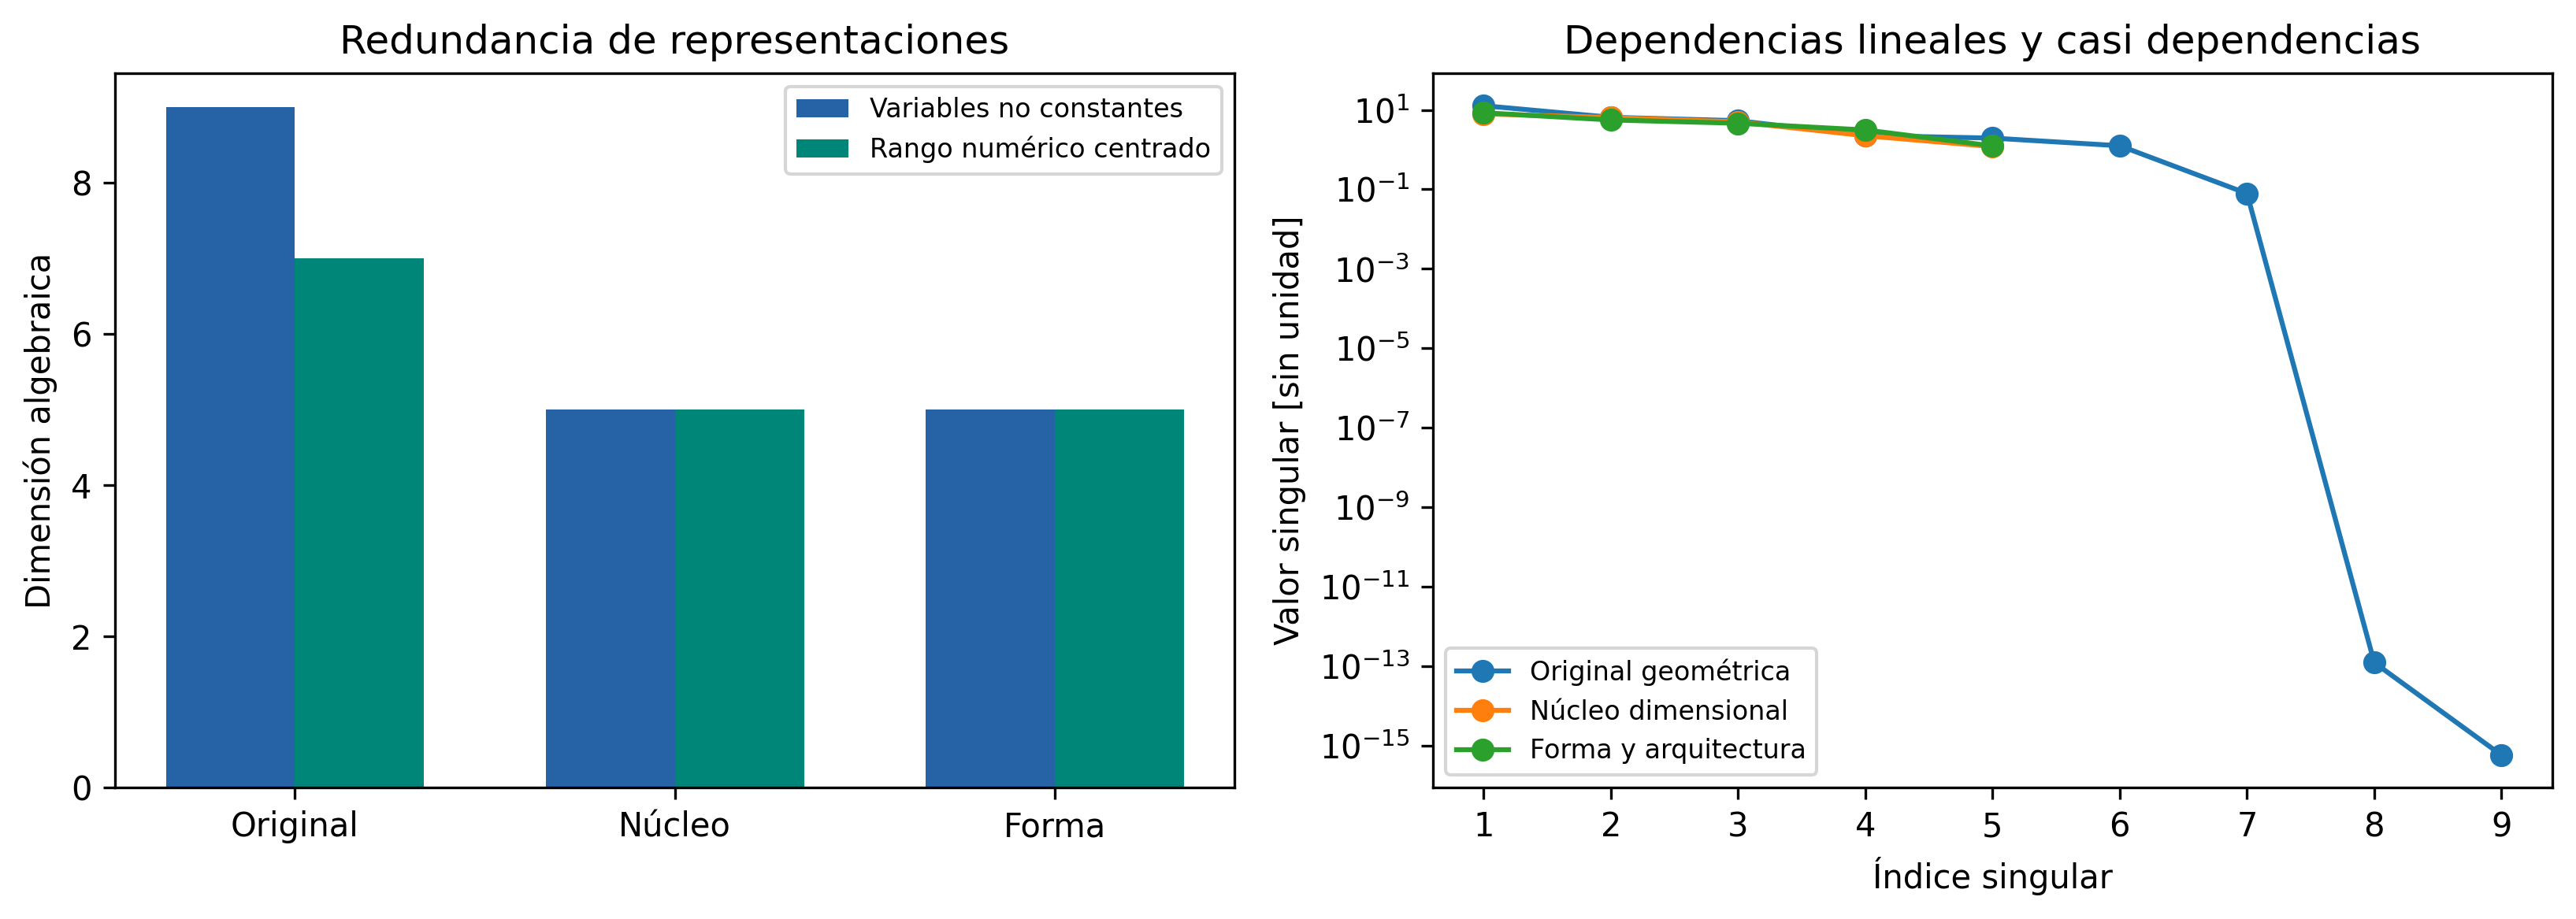

**Figura F01. Dimensión algebraica de representaciones geométricas.** Fuente: geometría del archivo MATLAB; exportaciones PNG300dpi y SVG en `reports/eda_transformaciones/figures`.

**Resultado.** La representación original tiene 9 columnas variables y rango 7. El núcleo dimensional alcanza rango 5; el cambio elimina redundancia lineal exacta en esta descripción, sin validar desempeño.

In [3]:
show_table('T03_representaciones')
show_figure('F01_representaciones')
r=result['tables']['T03_representaciones'].set_index('representacion')
display(Markdown(f"**Resultado.** La representación original tiene {int(r.loc['Original geométrica','columnas_variables'])} columnas variables y rango {int(r.loc['Original geométrica','rango_centrado'])}. El núcleo dimensional alcanza rango {int(r.loc['Núcleo dimensional','rango_centrado'])}; el cambio elimina redundancia lineal exacta en esta descripción, sin validar desempeño."))

## 3.3 Logaritmos: cambios de escala sin nueva información

**Pregunta.** ¿Qué cambia al usar una escala logarítmica de volumen?
**Método.** Se compara asimetría y ECDF usando ln(V / 1 mm³), con argumento adimensional.
**Límite.** El orden se conserva, pero la distancia cambia; una menor asimetría no es un criterio suficiente
para transformar ni impone normalidad al aprendizaje. No se transforma automáticamente el objetivo.


variable,asimetria_original,asimetria_log,rho_original_log,formula
Fiber_total_volume,-0.3747,-0.3861,1,ln(V / 1 mm³)
Pivot_total_volume,0.3747,-0.07372,1,ln(V / 1 mm³)
Sample_total_volume,-0.4878,-0.5069,1,ln(V / 1 mm³)


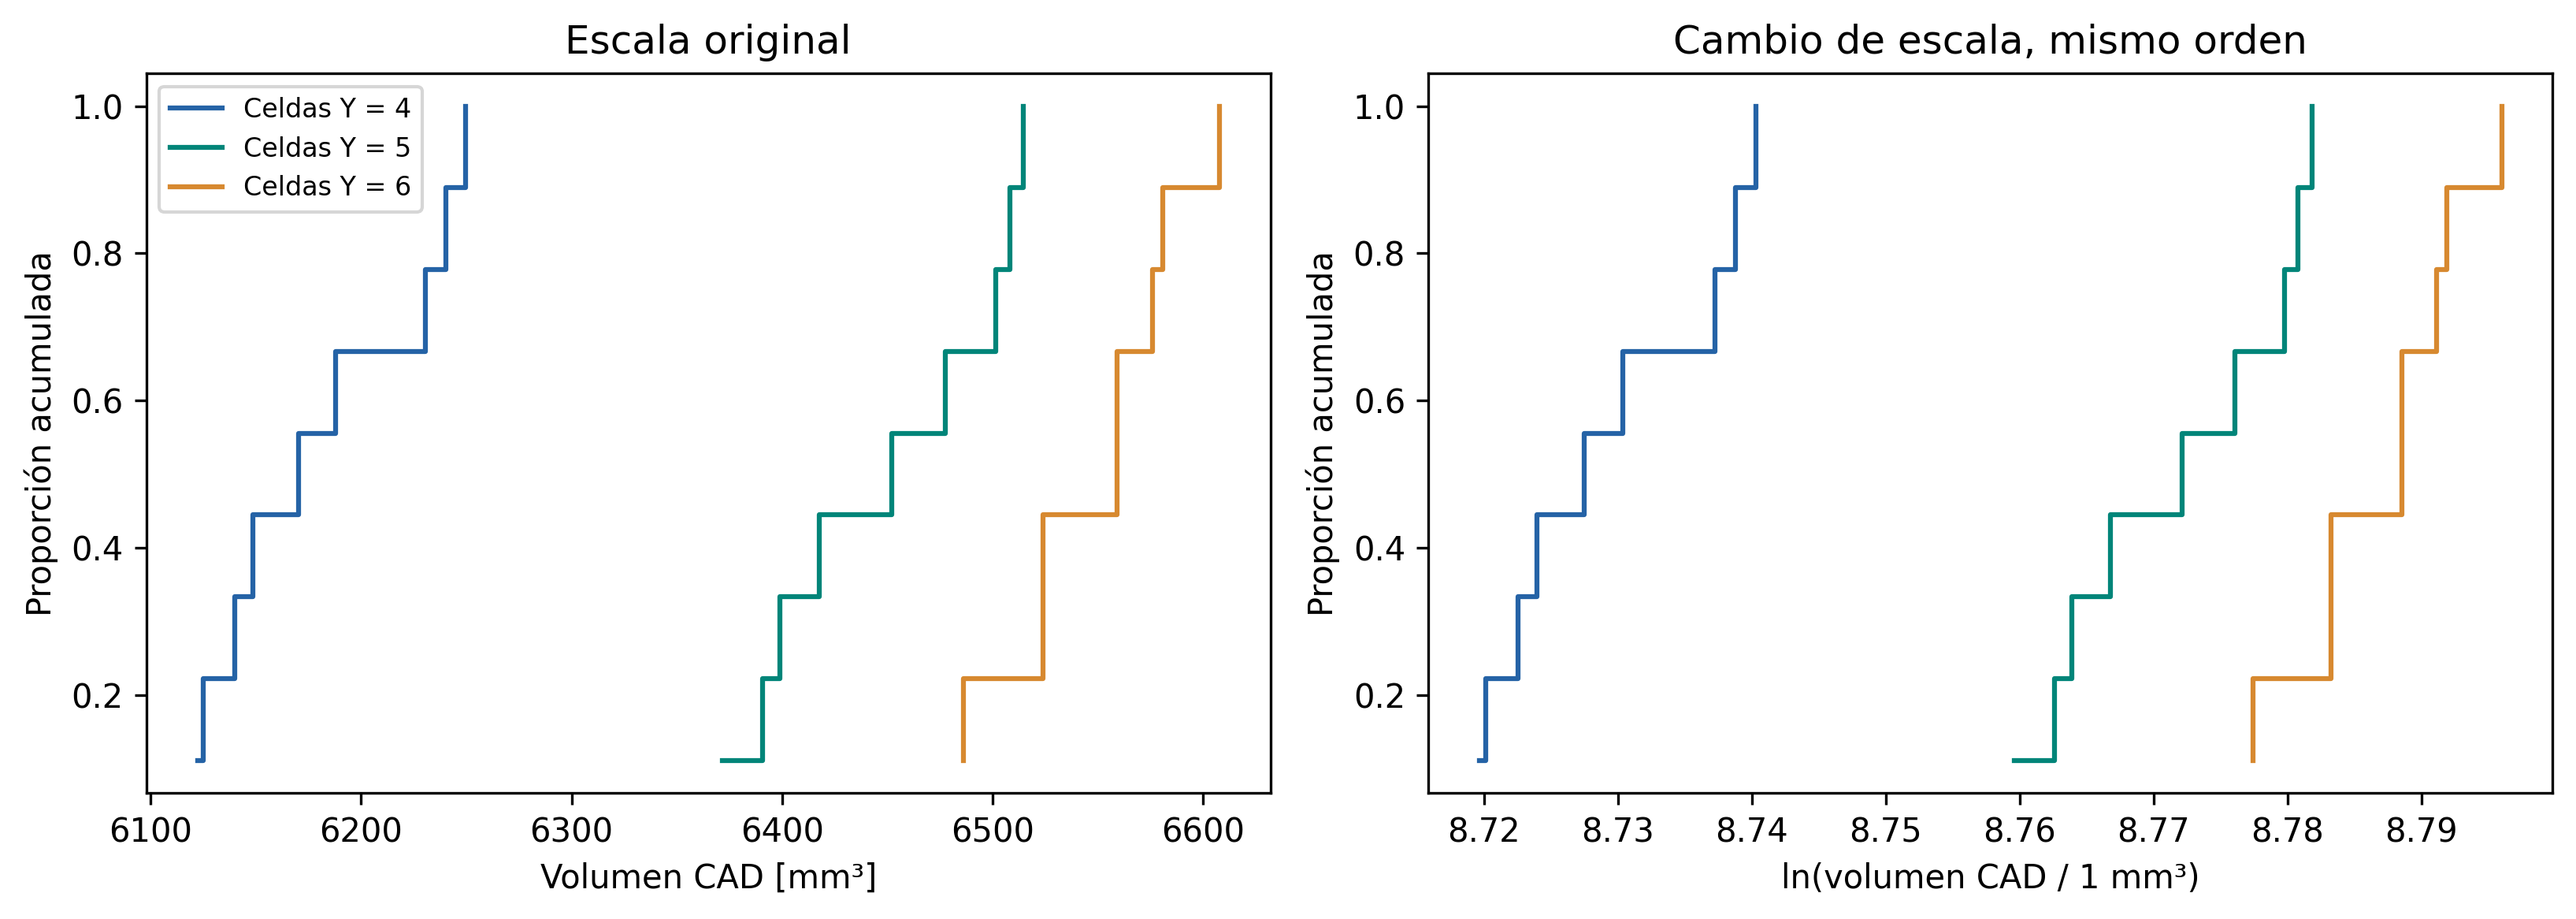

**Figura F02. Efecto del logaritmo sobre la distribución del volumen CAD.** Fuente: geometría del archivo MATLAB; exportaciones PNG300dpi y SVG en `reports/eda_transformaciones/figures`.

**Resultado.** La correlación de rangos original–logaritmo es uno: el orden geométrico se conserva. Las asimetrías calculadas muestran el efecto concreto del cambio de escala; no se elige una opción mirando su relación con el target.

In [4]:
show_table('T04_logaritmos')
show_figure('F02_logaritmos')
display(Markdown('**Resultado.** La correlación de rangos original–logaritmo es uno: el orden geométrico se conserva. Las asimetrías calculadas muestran el efecto concreto del cambio de escala; no se elige una opción mirando su relación con el target.'))

## 3.4 Escalamiento y comprobación del ajuste por subconjuntos

**Pregunta.** ¿Los casos reservados alteran los parámetros del preprocesamiento?
**Método.** Se usa una partición reproducible exclusivamente para comprobar aislamiento. Mediana,
constantes y centro/escala se estiman en train y se aplican a la parte reservada. Se verifica por cálculo
independiente el centro de cada transformación. Los tamaños de cada partición se conservan en la tabla técnica.
**Límite.** Este ejercicio prueba el código; no demuestra independencia experimental ni capacidad predictiva.


fold,escalamiento,n_train,n_reservado,constantes_en_train,error_centro_train,verificacion
1,standard,21,6,Pivot_radius,0,Verificado solo con entrenamiento
1,robust,21,6,Pivot_radius,0,Verificado solo con entrenamiento
2,standard,21,6,Pivot_radius,0,Verificado solo con entrenamiento
2,robust,21,6,Pivot_radius,0,Verificado solo con entrenamiento
3,standard,22,5,Pivot_radius,0,Verificado solo con entrenamiento
3,robust,22,5,Pivot_radius,0,Verificado solo con entrenamiento
4,standard,22,5,Pivot_radius,0,Verificado solo con entrenamiento
4,robust,22,5,Pivot_radius,0,Verificado solo con entrenamiento
5,standard,22,5,Pivot_radius,0,Verificado solo con entrenamiento
5,robust,22,5,Pivot_radius,0,Verificado solo con entrenamiento


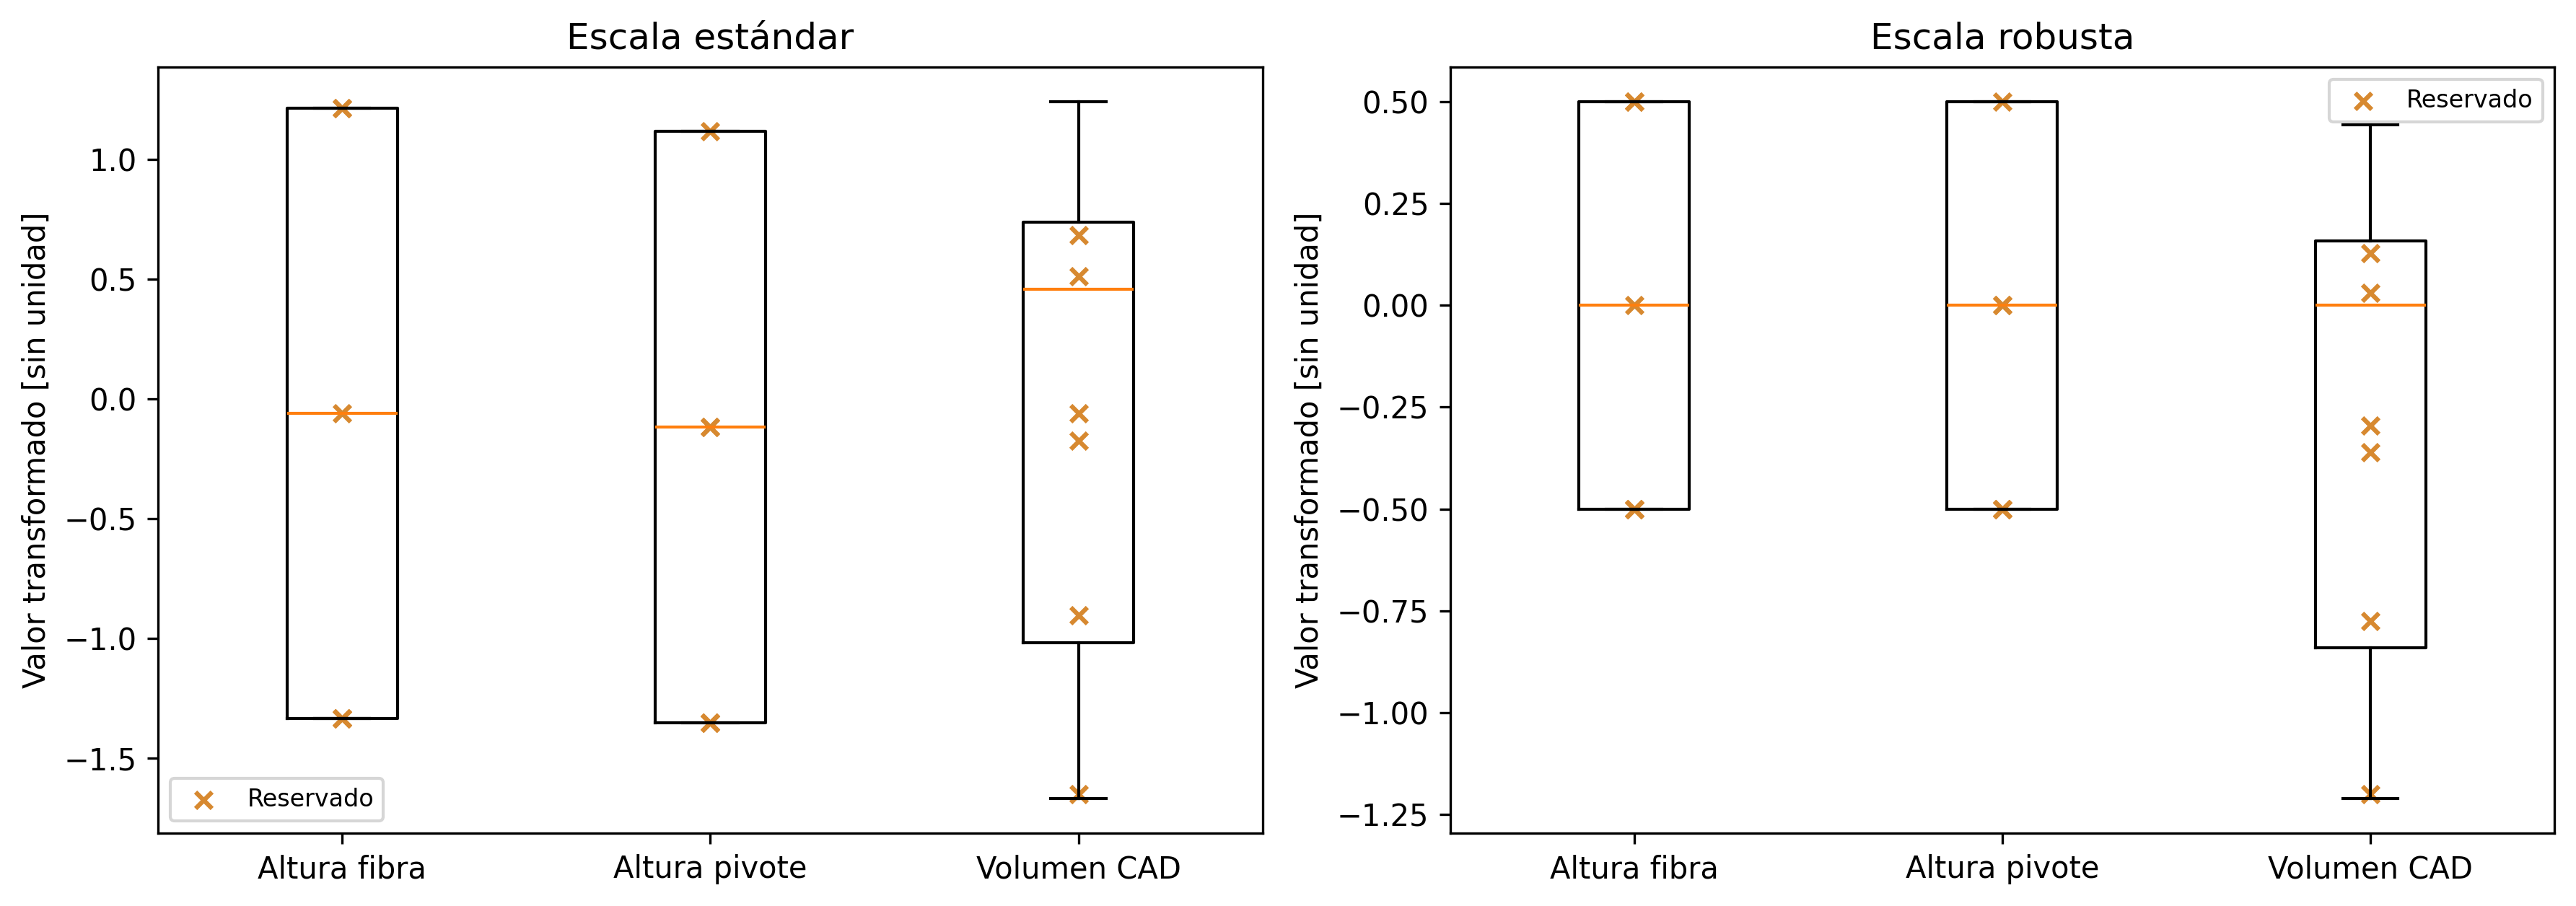

**Figura F03. Transformaciones ajustadas en entrenamiento y aplicadas a casos reservados.** Fuente: geometría del archivo MATLAB; exportaciones PNG300dpi y SVG en `reports/eda_transformaciones/figures`.

**Resultado.** El error máximo entre el centro ajustado y el centro calculado solo con train es 0. El radio de pivote se detecta como constante dentro de train. No se aprende ningún parámetro de los casos reservados.

In [5]:
show_table('T05_aislamiento_transformaciones')
show_figure('F03_escalamiento')
a=result['tables']['T05_aislamiento_transformaciones']
display(Markdown(f"**Resultado.** El error máximo entre el centro ajustado y el centro calculado solo con train es {a.error_centro_train.max():.2g}. El radio de pivote se detecta como constante dentro de train. No se aprende ningún parámetro de los casos reservados."))

## 3.5 Geometría previa y respuestas del ensayo

**Pregunta.** ¿Qué puede entrar al modelo que operará antes del ensayo?
**Método.** Se auditan roles por disponibilidad temporal. Las derivadas que contengan fuerza, residual,
energía o eventos conservan su condición posensayo aunque su nombre parezca geométrico.
**Límite.** Admisibilidad temporal no equivale a selección final; las alternativas deben compararse
con validación que respete réplicas y dependencias confirmadas.


In [6]:
show_table('T06_frontera_predictiva')
show_table('T07_decisiones')

variable,rol,admisible_temporalmente,decision
Case_n,identificador,False,Excluir de X
n_cells_Y,INPUT geométrico,True,Disponible antes del ensayo
Fiber_height,INPUT geométrico,True,Disponible antes del ensayo
Fiber_base,INPUT geométrico,True,Disponible antes del ensayo
Fiber_total_length,INPUT geométrico,True,Disponible antes del ensayo
Fiber_total_volume,INPUT geométrico,True,Disponible antes del ensayo
Pivot_height,INPUT geométrico,True,Disponible antes del ensayo
Pivot_radius,INPUT geométrico,True,Disponible antes del ensayo
Pivot_total_number,INPUT geométrico,True,Disponible antes del ensayo
Pivot_total_volume,INPUT geométrico,True,Disponible antes del ensayo


elemento,decision,justificacion
Fórmulas geométricas,"Candidatas, no selección definitiva",Construcción determinística sin target; contrastar geometría con fichas
Volúmenes fibra/pivote,Controlar redundancia,Su suma declarada es constante; no interpretar efectos independientes
Radio del pivote,Eliminar constante dentro de train,Fuera de este dominio podría variar; no se elimina de la fuente
Escala estándar/robusta,Comparar dentro de validación interna,"Este cuaderno verifica implementación, no cuál predice mejor"
Logaritmos,Alternativa descriptiva,Preservan orden; no crean información ni garantizan normalidad
Imputación,Solo predictores dentro de train,No imputar target ni completar eventos no observados
Particiones,Escenario demostrativo de aislamiento,Confirmar réplicas/lotes; una familia de diseño no es por sí sola una réplica
Transferencia,No evaluada,"Nuevas arquitecturas, materiales y protocolos requieren validación externa"


## 3.6 Interpretación de las transformaciones

El bloque geométrico original contiene dependencias: su rango numérico centrado es **7 entre 9 columnas variables**. Las dos representaciones reducidas tienen rango **5 entre 5** (§3.2). Con la tolerancia declarada se evita repetir algunas relaciones algebraicas; esto describe la representación de las variables y no demuestra una ventaja predictiva.

El logaritmo reduce la asimetría del volumen de pivotes, pero no la de todos los volúmenes (§3.3). Por tanto, no se justifica transformar todas las variables por una regla general. El orden se conserva, mientras que las distancias y la forma de la distribución cambian.

La comprobación del escalamiento confirma que los centros se calculan exclusivamente con el subconjunto de ajuste (§3.4). Las observaciones reservadas no alteran esos parámetros. Las fórmulas derivadas heredan las discrepancias de las geometrías documentadas; no las corrigen ni verifican independencia experimental.


## 3.7 Reproducción

Las representaciones geométricas y sus comprobaciones se guardan en `reports/eda_transformaciones/`. Se conservan la fuente original y las tablas preliminares. Los cambios de representación permiten examinar redundancia y escala sin añadir ensayos ni corregir geometrías por suposición.

Este cuaderno concluye en la caracterización de las variables. Reproducción de los tres cuadernos: `python -m src.reporte_eda --execute --all`.

Referencia metodológica: [scikit-learn, preprocesamiento](https://scikit-learn.org/stable/modules/preprocessing.html). Las definiciones físicas y su soporte documental están en el [diccionario](../docs/diccionario_datos.md).
